# Mobile Game A/B Test - Gate Placement & Retention (Cookie Cats)

**Business question:** Cookie Cats is a mobile puzzle game. Right now there's a gate at level 30 that pauses the player (wait or pay to continue). The product team wants to know what happens if we push that gate back to level 40 - does it help retention or hurt it?

Data is from a real A/B test run by the game (via DataCamp's public dataset, originally released by the developers). 90,189 users, split into:
- `gate_30` - control, gate stays at level 30
- `gate_40` - treatment, gate moved to level 40

Columns: `userid`, `version`, `sum_gamerounds` (rounds played in first 14 days), `retention_1` (came back day 1), `retention_7` (came back day 7).

I'm going to check the data first, run the main hypothesis test on retention, do a bootstrap to make sure the result holds up, then break it down by how engaged the player is (cohort-style), and finally fit a small logistic regression to see what's actually driving retention.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('cookie_cats.csv')
df.shape

## 1. Basic checks

In [2]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [1]:
# checking for duplicates 
df['userid'].duplicated().sum()

NameError: name 'df' is not defined

In [5]:
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Group sizes look close to 50/50 (44,700 vs 45,489), good sign. now running a quick chi-square just to confirm the split isn't skewed in some biased way.

In [6]:
obs_30 = df['version'].value_counts()['gate_30']
obs_40 = df['version'].value_counts()['gate_40']
chi2, p_balance, dof, exp = stats.chi2_contingency([[obs_30, obs_40]])
print(f"gate_30: {obs_30}, gate_40: {obs_40}")
print(f"chi2 = {chi2:.4f}, p-value = {p_balance:.4f}")

gate_30: 44700, gate_40: 45489
chi2 = 0.0000, p-value = 1.0000


p-value is basically 1, so data is randomized 100%

In [7]:
df['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Mean is ~52 rounds but the median is only 16, so it's heavily right skewed - most players don't play a ton, but there's a long tail of hardcore players. Let's look at the top few rows sorted by rounds played, since a 195 std dev vs 16 median usually means there's an outlier somewhere.

In [8]:
df.sort_values('sum_gamerounds', ascending=False).head(5)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True


There's one user with almost 50,000 rounds played in 14 days (basically impossible, most likely a bot account)

In [9]:
df = df[df['sum_gamerounds'] < df['sum_gamerounds'].max()].copy()
df.shape

(90188, 5)

## 2. Retention rates by group

The whole point of the test is retention, so let's just look at the raw numbers first before testing anything.

In [10]:
retention_summary = df.groupby('version')[['retention_1','retention_7']].mean()
retention_summary

,retention_1,retention_7
version,,
gate_30,0.448198,0.190183
gate_40,0.442283,0.182000


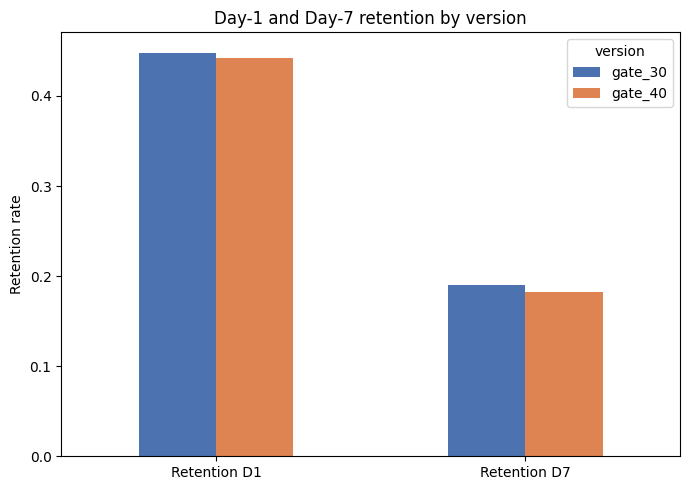

In [11]:
fig, ax = plt.subplots(figsize=(7,5))
retention_summary.T.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.set_ylabel('Retention rate')
ax.set_title('Day-1 and Day-7 retention by version')
ax.set_xticklabels(['Retention D1','Retention D7'], rotation=0)
plt.tight_layout()
plt.savefig('retention_by_version.png', dpi=120)
plt.show()

gate_30 (the current setup) actually has slightly higher retention on both day 1 and day 7 compared to gate_40. That's a bit strange, we would think pushing the gate later (giving people more free play before the paywall/wait) would keep them around longer, but it's the opposite here. Need to check if this difference is actually statistically significant or just noise.

## 3. Hypothesis testing (two-proportion z-test)

**H0:** retention rate is the same for gate_30 and gate_40
**H1:** retention rate is different between the two versions

In [12]:
succ1 = df.groupby('version')['retention_1'].sum()
n1 = df.groupby('version')['retention_1'].count()
z1, p1 = proportions_ztest([succ1['gate_30'], succ1['gate_40']], [n1['gate_30'], n1['gate_40']])
print(f"Retention Day 1 -> z = {z1:.3f}, p-value = {p1:.4f}")

Retention Day 1 -> z = 1.787, p-value = 0.0739


In [13]:
succ7 = df.groupby('version')['retention_7'].sum()
n7 = df.groupby('version')['retention_7'].count()
z7, p7 = proportions_ztest([succ7['gate_30'], succ7['gate_40']], [n7['gate_30'], n7['gate_40']])
print(f"Retention Day 7 -> z = {z7:.3f}, p-value = {p7:.4f}")

Retention Day 7 -> z = 3.157, p-value = 0.0016


Day-1 retention difference is not significant at the usual 0.05 cutoff (p = 0.074), so we can't really say much there. But day-7 retention IS significant (p = 0.0016) - and gate_30 is the higher one. So keeping the gate at level 30 seems to actually be better for getting people to stick around a week later, moving it to level 40 hurts retention slightly.

This kind of makes sense if you think about it - the gate at level 30 gives players a natural break earlier on, maybe stops people from burning through content too fast and getting bored, or it self-selects for people who are more into the game since they have to make a choice earlier. Either way it's a decent signal against moving the gate later.

## 4. Robustness check - bootstrapping

The z-test says it's significant but doing a bootstrap on top of it just to make sure this isn't some artifact of the z-test assumptions. Resampling the whole dataset with replacement 5,000 times and recomputing the retention_7 difference each time.

In [14]:
np.random.seed(42)
n_iterations = 5000
boot_diffs = np.empty(n_iterations)

for i in range(n_iterations):
    sample = df.sample(frac=1, replace=True)
    rates = sample.groupby('version')['retention_7'].mean()
    boot_diffs[i] = rates['gate_30'] - rates['gate_40']

print(f"mean bootstrapped diff: {boot_diffs.mean():.4f}")
print(f"95% CI: {np.percentile(boot_diffs, 2.5):.4f} to {np.percentile(boot_diffs, 97.5):.4f}")
print(f"% of samples where gate_30 > gate_40: {(boot_diffs > 0).mean()*100:.2f}%")

mean bootstrapped diff: 0.0082
95% CI: 0.0032 to 0.0132
% of samples where gate_30 > gate_40: 99.98%


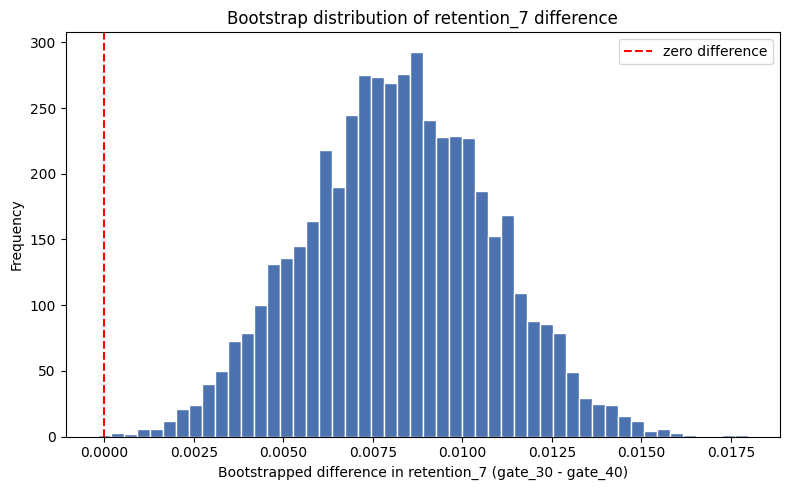

In [15]:
plt.figure(figsize=(8,5))
plt.hist(boot_diffs, bins=50, color='#4C72B0', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='zero difference')
plt.xlabel('Bootstrapped difference in retention_7 (gate_30 - gate_40)')
plt.ylabel('Frequency')
plt.title('Bootstrap distribution of retention_7 difference')
plt.legend()
plt.tight_layout()
plt.savefig('bootstrap_dist.png', dpi=120)
plt.show()

99.98% of the 5,000 resamples show gate_30 ahead of gate_40, and the 95% CI doesn't cross zero. So the z-test result isn't a fluke, it holds up under resampling too. Pretty confident now that the retention_7 difference is real and not just sampling noise.

## 5. Cohort analysis by engagement level

Splitting users into 4 cohorts based on how many rounds they played (quartiles of `sum_gamerounds`), then checking if the gate placement affects retention differently depending on how engaged the player already is. This is basically a cohort breakdown, just using engagement level instead of signup date since there's no date column in this dataset.

In [16]:
df['engagement_cohort'] = pd.qcut(df['sum_gamerounds'], 4, labels=['Low','Mid-Low','Mid-High','High'])
cohort_retention = df.groupby(['engagement_cohort','version'])['retention_7'].mean().unstack()
cohort_retention

version,gate_30,gate_40
engagement_cohort,,
Low,0.012193,0.013111
Mid-Low,0.041728,0.040937
Mid-High,0.147725,0.132188
High,0.567469,0.542494


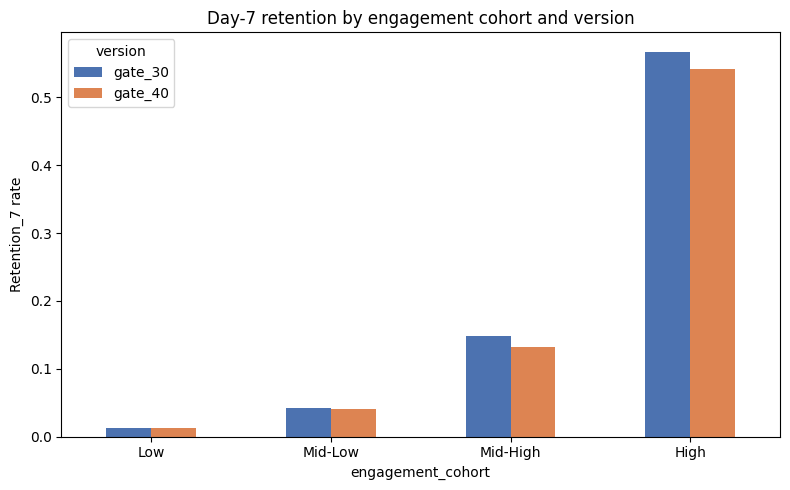

In [17]:
ax = cohort_retention.plot(kind='bar', figsize=(8,5), color=['#4C72B0','#DD8452'])
ax.set_ylabel('Retention_7 rate')
ax.set_title('Day-7 retention by engagement cohort and version')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=120)
plt.show()

The gap between gate_30 and gate_40 isn't the same across cohorts. It's small for Low and Mid-Low engagement users, but shows up more clearly in the Mid-High and High cohorts - the more engaged players are the ones retaining noticeably better under gate_30. Makes sense, casual players barely reach level 30 or 40 anyway so the gate position probably doesn't matter much to them, but for players who are already playing a lot, running into the gate later (level 40) seems to be a bit more of a letdown / stopping point than hitting it earlier at level 30.

Running a two-way ANOVA to check if this interaction (version x engagement cohort) is actually statistically meaningful and not just something that looks different in the chart.

In [18]:
df['retention_7_num'] = df['retention_7'].astype(int)
model = smf.ols('retention_7_num ~ C(version) * C(engagement_cohort)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(version),2.272382,1.0,21.837649,0.000003
C(engagement_cohort),4269.924877,3.0,13678.030253,0.000000
C(version):C(engagement_cohort),2.599902,3.0,8.328377,0.000016
Residual,9383.949256,90180.0,NaN,NaN


All three rows are significant (p < 0.05), including the interaction term `version:engagement_cohort`. So the effect of the gate placement really does depend on how engaged the player is - it's not a flat effect across everyone, which is useful for the recommendation later (this isn't a "change it for all users" situation, it matters more for some segments than others).

## 6. Logistic regression - what actually predicts retention

Building a simple logistic regression to predict retention_7 using version and sum_gamerounds together, just to see how much of the retention difference is really about the gate vs just how much someone is already playing.

In [19]:
df['version_num'] = (df['version'] == 'gate_40').astype(int)

X = df[['version_num', 'sum_gamerounds']]
X = sm.add_constant(X)
y = df['retention_7_num']

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.332137
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:        retention_7_num   No. Observations:                90188
Model:                          Logit   Df Residuals:                    90185
Method:                           MLE   Df Model:                            2
Date:                Sat, 18 Jul 2026   Pseudo R-squ.:                  0.3087
Time:                        14:55:04   Log-Likelihood:                -29955.
converged:                       True   LL-Null:                       -43331.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.6932      0.018   -147.963      0.000      -2.729      -2.658
version_num      

`sum_gamerounds` is (unsurprisingly) the strongest predictor - the more someone plays early on, the more likely they come back a week later, no surprise there. But `version_num` (gate_40) is still negative and significant even after controlling for how much someone played, coefficient of about -0.083, p < 0.001. So even accounting for engagement level, being in the gate_40 group independently lowers the odds of retention a bit. It's not a huge effect size but it's consistent and it's not just noise from engagement differences between groups.

## 7. Summary and recommendation

- Retention_1 difference between gate_30 and gate_40 is not statistically significant (p = 0.074) - basically no meaningful impact on next-day return.
- Retention_7 difference IS significant (p = 0.0016) and gate_30 comes out ahead. Confirmed with a 5,000-run bootstrap, 99.98% of resamples favor gate_30, 95% CI does not include zero.
- The effect isn't uniform - ANOVA shows a real interaction between engagement cohort and version, the gap is bigger for players who already play a lot.
- Logistic regression backs this up - version still matters for retention even after controlling for how much a user plays.

**Recommendation:** don't move the gate to level 40. The data doesn't support it, retention is either flat or a bit worse, and the drop is concentrated in more engaged players, which are exactly the users you don't want to lose since they're likely the ones driving long-term revenue (IAP, ad views, etc). Keeping the gate at level 30 is the safer call here based on what the test actually shows, even though the "move it later" idea sounds reasonable on paper.

If the product team really wants to explore moving the gate later, this suggests it'd be worth testing a version that treats highly engaged players differently (maybe a softer gate or an alternate unlock path for them specifically) rather than rolling gate_40 out to everyone.